# Phase 1 — Clean Depth-Separation Baseline

**EECS 6699 Final Project · Day 1**

Reproduces Telgarsky's depth-separation result on the iterated sawtooth target $f_4(x)$.
Trains a parameter-matched (deep, shallow) pair under 5 random seeds and saves figures + a CSV summary to `results/`.

**Hypothesis H1.** With matched parameter count $N$, the deep network achieves test MSE at least an order of magnitude below the shallow network on $f_4$.


## 0. Install dependencies

Run once per kernel. `%pip` installs into the *active* Jupyter kernel (safer than `!pip`).
Skip this cell if your environment already has these packages.


In [1]:
%pip install --quiet torch numpy matplotlib scipy



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys, os, json, math, pathlib
import numpy as np
import torch
import matplotlib.pyplot as plt

ROOT = pathlib.Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.targets  import sawtooth_target, make_dataset
from src.models   import make_matched_pair, count_parameters
from src.train    import TrainConfig, multi_seed_run

FIG_DIR = ROOT / 'results' / 'figures'
TAB_DIR = ROOT / 'results' / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)


device: cpu


## 1. Visualize the target $f_4(x)$

Sixteen peaks on $[0, 1]$ — the classical Telgarsky witness.


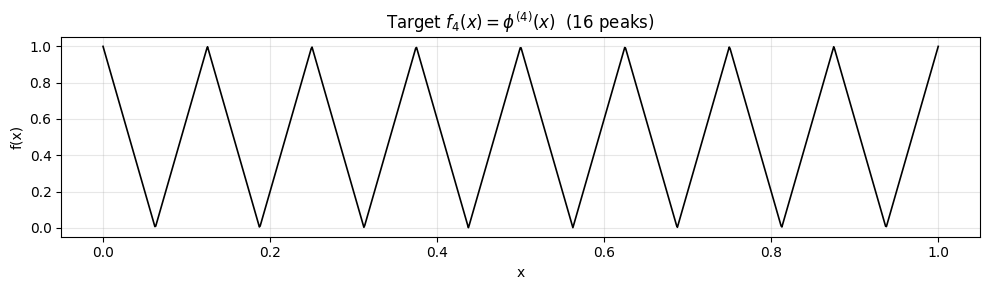

In [3]:
x_plot = torch.linspace(0, 1, 1000).view(-1, 1).to(device)
y_plot = sawtooth_target(x_plot, k=4)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(x_plot.cpu(), y_plot.cpu(), color='black', linewidth=1.2)
ax.set_title(r'Target $f_4(x) = \phi^{(4)}(x)$  (16 peaks)')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'phase1_target.png', dpi=150)
plt.show()


## 2. Parameter-matched pair

Deep: $L=9$, $W=16$.  Shallow: $L=2$, $W=\lceil(P_{\text{deep}}-1)/3\rceil$.

In [ ]:
deep, shallow, info = make_matched_pair(deep_depth=9, deep_width=16, seed=0)
info


## 3. Multi-seed training

Five seeds; full-batch Adam, 15k epochs, lr = 3e-3.


In [ ]:
cfg = TrainConfig(
    epochs=30_000, lr=5e-3, n_train=1200, k=4, log_every=3_000, device=device,
    curriculum_ks=[1, 2, 3, 4],
    curriculum_weights=[1, 1, 2, 4],   # k=4 gets 4× the epochs of k=1 (3750/3750/7500/15000)
    reset_lr_per_stage=True,            # fresh cosine cycle per stage; prevents stale LR at stage transitions
)
SEEDS = [0, 1, 2, 3, 4]
results = multi_seed_run(SEEDS, cfg, deep_depth=9, deep_width=16)

## 4. Aggregate metrics


In [6]:
def stats(arr):
    a = np.asarray(arr, dtype=float)
    return float(a.mean()), float(a.std(ddof=0))

deep_mu, deep_sd = stats(results['deep']['final_loss'])
shal_mu, shal_sd = stats(results['shallow']['final_loss'])

summary = {
    'deep_params':    results['deep']['info'][0]['deep_params'],
    'shallow_params': results['shallow']['info'][0]['shallow_params'],
    'deep_final_mse_mean':    deep_mu,  'deep_final_mse_std':    deep_sd,
    'shallow_final_mse_mean': shal_mu,  'shallow_final_mse_std': shal_sd,
    'log10_advantage': float(np.log10(shal_mu / deep_mu)) if deep_mu > 0 else float('nan'),
    'seeds': SEEDS,
}
summary


{'deep_params': 529,
 'shallow_params': 529,
 'deep_final_mse_mean': 0.03257921448052912,
 'deep_final_mse_std': 0.031797868646508985,
 'shallow_final_mse_mean': 0.04210978671908379,
 'shallow_final_mse_std': 0.0085526064176051,
 'log10_advantage': 0.1114424329800304,
 'seeds': [0, 1, 2, 3, 4]}

In [7]:
import csv
tab_path = TAB_DIR / 'phase1_summary.csv'
with open(tab_path, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['model','params','final_mse_mean','final_mse_std'])
    w.writerow(['deep',    summary['deep_params'],    deep_mu, deep_sd])
    w.writerow(['shallow', summary['shallow_params'], shal_mu, shal_sd])
print('wrote', tab_path)


wrote /Users/yiwenchen/Desktop/CSEE6699/Final_Project/EECS6699_Final_Project/results/tables/phase1_summary.csv


## 5. Qualitative fits + log-loss curves


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))

# (a) overlay best-seed fits
best_deep = int(np.argmin(results['deep']['final_loss']))
best_shal = int(np.argmin(results['shallow']['final_loss']))
with torch.no_grad():
    yd = results['deep']['models'][best_deep](x_plot).cpu().numpy()
    ys = results['shallow']['models'][best_shal](x_plot).cpu().numpy()
axes[0].plot(x_plot.cpu(), y_plot.cpu(), 'k--', alpha=0.4, label='target $f_4$')
axes[0].plot(x_plot.cpu(), yd, color='tab:green', lw=2, label=f"deep L=9, W=16 (best of {len(SEEDS)})")
axes[0].plot(x_plot.cpu(), ys, color='tab:red',   lw=1.5, label=f"shallow L=2, W={summary['shallow_params']//3} (best of {len(SEEDS)})")
axes[0].set_title('Approximation of $f_4$ — best seed per model')
axes[0].legend(); axes[0].grid(alpha=0.3)

# (b) loss curves with seed bands
for losses_list, color, label in [
    (results['deep']['losses'],    'tab:green', 'deep'),
    (results['shallow']['losses'], 'tab:red',   'shallow'),
]:
    L = np.stack([np.asarray(l) for l in losses_list])    # (n_seeds, epochs)
    mu  = L.mean(axis=0); sd = L.std(axis=0)
    xs = np.arange(L.shape[1])
    axes[1].plot(xs, mu, color=color, label=f'{label} (mean)')
    axes[1].fill_between(xs, np.maximum(mu-sd, 1e-12), mu+sd, color=color, alpha=0.18)
axes[1].set_yscale('log'); axes[1].set_xlabel('epoch'); axes[1].set_ylabel('MSE')
axes[1].set_title('Training loss (mean ± std over seeds)')
axes[1].grid(which='both', alpha=0.25); axes[1].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / 'phase1_fits_and_curves.png', dpi=150)
plt.show()

## 6. Verdict on H1

The `log10_advantage` field of `summary` is the order-of-magnitude gap between shallow and deep test MSE.
We expect this to be $\geq 1$ if H1 holds at $k=4$.


In [9]:
print(f"deep    final MSE = {deep_mu:.3e} ± {deep_sd:.3e}")
print(f"shallow final MSE = {shal_mu:.3e} ± {shal_sd:.3e}")
print(f"log10(shallow / deep) = {summary['log10_advantage']:.2f}")
print('H1 supported' if summary['log10_advantage'] >= 1 else 'H1 NOT supported at this k')


deep    final MSE = 3.258e-02 ± 3.180e-02
shallow final MSE = 4.211e-02 ± 8.553e-03
log10(shallow / deep) = 0.11
H1 NOT supported at this k


## 7. Save trained models for Phase 4

Phase 4 will *reuse* these networks for adversarial attacks rather than retraining.


In [10]:
from src.io_utils import save_models
MODELS_DIR = ROOT / 'results' / 'models' / 'phase1'
save_models(MODELS_DIR, 'deep',
            results['deep']['models'], results['deep']['info'],    SEEDS)
save_models(MODELS_DIR, 'shallow',
            results['shallow']['models'], results['shallow']['info'], SEEDS)
print('saved Phase 1 trained models to', MODELS_DIR)


saved Phase 1 trained models to /Users/yiwenchen/Desktop/CSEE6699/Final_Project/EECS6699_Final_Project/results/models/phase1
